# VEST 39915, 316 ms: self-consistent kinetic inference

This is an executable archive of the kinetic-state **closure on a fixed magnetic equilibrium**. It uses the real magnetic-only EFIT and Thomson/core_profiles slices at 316 ms, the time-matched OpenADAS transient C/O case from [PR #1577](https://github.com/VEST-Tokamak/vaft/pull/1577), and VAFT's pressure-partition API. The compact snapshot in `workflow/kinetic_state/archive_data` preserves the input arrays, source-product SHA-256 values, plasma age, and charge-state fractions. Re-running the archived algebra does not require the campaign server.

**Status of each quantity.** Mapped Thomson points and their 1σ errors are measurements; fitted $n_e,T_e$ and magnetic $p_{\rm eq}$ are reconstructions. The elemental ratio $n_C=n_O$ and $\langle Z_{\rm eff}\rangle_{n_e dV}=2$ are assumptions. Charge states and $Z_{\rm eff}(\rho)$ are model-derived; $T_i$ is inferred by pressure partition. $p_{\rm kin}=p_{\rm eq}$ is imposed by the closure and is not an independent validation of the equilibrium. A resistive $Z_{\rm eff}$ estimate for this shot hit its lower bound and does not constrain the composition.

The notebook records alignment with Thomson where measurements exist. It does not claim that the magnetic equilibrium has been refitted after adding these kinetic profiles.

In [ ]:
from pathlib import Path
import csv, hashlib, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import vaft
import vaft.omas
from vaft.plot import FORMATS, Panels, Profile1D, Series, render_panels
from vaft.validation.kinetic_state import infer_ti_pressure_partition

ROOT = Path.cwd()
if not (ROOT / "workflow" / "kinetic_state").exists():
    ROOT = Path.cwd().parent
assert (ROOT / "workflow" / "kinetic_state").exists(), "Run from the repository root or notebooks/"
SNAPSHOT = ROOT / "workflow" / "kinetic_state" / "archive_data" / "vest_39915_316ms.json"
s = json.loads(SNAPSHOT.read_text())
assert (s["machine"], s["shot"], s["time_s"]) == ("VEST", 39915, 0.316)
print("Snapshot:", SNAPSHOT.relative_to(ROOT))
for name, provenance in s["provenance"].items():
    print(f"{name:24s}", provenance.get("sha256", provenance.get("profile_sha256", "")))

Snapshot: workflow/kinetic_state/archive_data/vest_39915_316ms.json
magnetic_efit            8f49e898e002ad6f473632849e6aa959da642ff1a838b0dcfc4b676bc055d465
core_profiles            e4473f3dcd4f9269a083bd974fd83385f5ac70e09832d20de9dd2a9bd9b28e2d
electron_efit            5cdc39024ebaea6d64f31f63046fb69a4250339e03e169ab3d89657b6f7f31bb
resistive_zeff_atlas     70ed64794b8eb267958737666aaf0e797d95753074129774c61e8eb3f14acf17
impurity_atlas           306b51bca4d4eaa7d6b7367640fb00d6222cdae27142efaa366c7566a0aa046b
electron_kinetic_state_atlas d023ee87da53b7cf09a48a79663d2987f423bafe696099781a1b4100f202480a
electron_efit_manifest   cd2d172bb406c822f8cfe83dc59061edd366716bdf69aaecdecbe85d18b9524c


## 1. Time and flux-coordinate alignment

Select by physical time, not array index. The archived magnetic EFIT and Thomson fit are both at 0.316 s. Their 129-point $\rho_{\rm tor,N}$ and $\psi$ grids coincide. Mapped Thomson points have their own sparse radial positions; they are not interpreted as 129 independent measurements.

In [ ]:
eq, cp, ts = s["magnetic_equilibrium"], s["core_profiles"], s["mapped_thomson"]
rho = np.asarray(cp["rho_tor_norm"], float)
psi = np.asarray(cp["psi_Wb"], float)
volume = np.asarray(eq["volume_m3"], float)
ne = np.asarray(cp["electron_density_m3"], float)
te = np.asarray(cp["electron_temperature_eV"], float)
peq = np.asarray(eq["pressure_Pa"], float)
assert eq["time_s"] == cp["time_s"] == s["time_s"]
np.testing.assert_allclose(rho, eq["rho_tor_norm"], rtol=0, atol=1e-10)
np.testing.assert_allclose(psi, eq["psi_Wb"], rtol=0, atol=1e-10)
assert np.all(np.diff(rho) > 0)
rho_ts = np.asarray(ts["rho_tor_norm"], float)
np.testing.assert_allclose(rho_ts, ts["density_rho_tor_norm"], rtol=0, atol=1e-10)
assert rho_ts.size == 5
print(f"EFIT/core_profiles: {eq['time_s']*1e3:.0f} ms, {len(rho)} common radial points")
print(f"Mapped TS: {len(rho_ts)} measured points, rho={rho_ts.min():.3f}–{rho_ts.max():.3f}")

EFIT/core_profiles: 316 ms, 129 common radial points
Mapped TS: 5 measured points, rho=0.036–0.530


## 2. Measurement-versus-fit alignment

The fit is compared to each mapped Thomson point using its own reported 1σ error. A residual below 1σ is a local agreement check; five points do not validate the extrapolated profile beyond the last measured radius. Thomson electron pressure is $p_e^{\rm TS}=e n_e^{\rm TS}T_e^{\rm TS}$; its displayed error uses independent $n_e$ and $T_e$ errors.

In [ ]:
E = 1.602176634e-19
ne_ts = np.asarray(ts["electron_density_m3"], float)
te_ts = np.asarray(ts["electron_temperature_eV"], float)
sne_ts = np.asarray(ts["electron_density_error_m3"], float)
ste_ts = np.asarray(ts["electron_temperature_error_eV"], float)
p_ts = E * ne_ts * te_ts
sp_ts = E * np.hypot(te_ts * sne_ts, ne_ts * ste_ts)
z_ne = (ne_ts - np.interp(rho_ts, rho, ne)) / sne_ts
z_te = (te_ts - np.interp(rho_ts, rho, te)) / ste_ts
print("rho      ne residual/σ   Te residual/σ")
for r, a, b in zip(rho_ts, z_ne, z_te):
    print(f"{r:5.3f}    {a:+8.3f}         {b:+8.3f}")
print(f"sum(residual²): ne={np.sum(z_ne**2):.3f}, Te={np.sum(z_te**2):.3f} (five points each)")

rho      ne residual/σ   Te residual/σ
0.169      -0.867           -0.011
0.036      -0.347           +0.046
0.170      +0.840           +0.215
0.362      +0.759           +0.413
0.530      -0.483           -0.469
sum(residual²): ne=2.386, Te=0.440 (five points each)


## 3. Transient OpenADAS charge states and the assumed normalization

The atlas records a plasma age of 9.68 ms from the H-α onset. For C and O, it computes transient charge-state fractions from neutral initial states and ADF11 rates. The archived charge fractions below are the exact output used for this case; raw ADF11 file hashes are recorded. This cell reconstructs moments and density from those fractions without network access.

For equal elemental densities $n_C=n_O=c n_e/2$, define $\langle Z\rangle_s=\sum_q q f_{s,q}$ and $\langle Z^2\rangle_s=\sum_q q^2f_{s,q}$. Quasineutrality sets $n_H=n_e-n_C\langle Z\rangle_C-n_O\langle Z\rangle_O$. The elemental densities include neutral states, but only charged C/O states enter the ion pressure sum.

In [ ]:
model = s["impurity_model"]
archive = s["openadas_charge_states"]
assert model["ionization"] == "transient" and model["normalization"] == "ne_weighted_mean"
assert model["elemental_weights"] == {"C": 1.0, "O": 1.0}
c = float(archive["scale"])
fC = np.asarray(archive["C"], float)
fO = np.asarray(archive["O"], float)
assert fC.shape == (rho.size, 7) and fO.shape == (rho.size, 9)
valid_charge = np.isfinite(fC).all(axis=1) & np.isfinite(fO).all(axis=1)
np.testing.assert_allclose(fC[valid_charge].sum(axis=1), 1.0, atol=1e-12)
np.testing.assert_allclose(fO[valid_charge].sum(axis=1), 1.0, atol=1e-12)
qC, qO = np.arange(7), np.arange(9)
zC, zO = fC @ qC, fO @ qO
z2C, z2O = fC @ (qC**2), fO @ (qO**2)
nC = 0.5 * c * ne
nO = 0.5 * c * ne
nH = ne - nC*zC - nO*zO
nC_ion, nO_ion = nC*(1-fC[:,0]), nO*(1-fO[:,0])
nimp = nC_ion + nO_ion
nion = nH + nimp
zeff = (nH + nC*z2C + nO*z2O) / ne
np.testing.assert_allclose(nC[valid_charge], nO[valid_charge], atol=0)
np.testing.assert_allclose(ne[valid_charge], (nH+nC*zC+nO*zO)[valid_charge], rtol=1e-12)
assert np.all(nH[valid_charge] >= 0)
print(f"n_C/n_e = n_O/n_e = {c/2:.6f} (assumed elemental ratio, model-normalized scale)")
print(f"Z_eff axis = {zeff[0]:.6f}; rho=0.9 = {np.interp(0.9, rho[valid_charge], zeff[valid_charge]):.6f}")
print(f"Finite charge-state points: {valid_charge.sum()}/{rho.size}")

n_C/n_e = n_O/n_e = 0.022884 (assumed elemental ratio, model-normalized scale)
Z_eff axis = 1.327684; rho=0.9 = 1.719022
Finite charge-state points: 128/129


The fixed EFIT volume supplies shell weights $dV$. The assumed target applies to the $n_e dV$-weighted **mean**, not to every radius. The original atlas row for this same snapshot gives axis $Z_{\rm eff}=1.327684$, $Z_{\rm eff}(0.9)=1.719022$, and mean 2. These values are checked below. The coronal validity check fails at 127 of 128 finite points, so the coronal-equilibrium profile is not used.

In [ ]:
edges = np.concatenate(([0.0], 0.5*(rho[:-1]+rho[1:]), [rho[-1]]))
dV = np.clip(np.diff(np.interp(edges, rho, volume)), 0.0, None)
zeff_mean = np.sum((ne*dV*zeff)[valid_charge]) / np.sum((ne*dV)[valid_charge])
np.testing.assert_allclose(zeff_mean, 2.0, rtol=1e-12)
np.testing.assert_allclose(zeff[0], 1.3276842011353556, rtol=1e-12)
np.testing.assert_allclose(np.interp(.9, rho[valid_charge], zeff[valid_charge]),
                           1.7190221792755789, rtol=1e-12)
print(f"<Z_eff>_ne,dV = {zeff_mean:.12f}")
print(f"Z_eff min/max on finite grid = {np.nanmin(zeff):.3f}/{np.nanmax(zeff):.3f}")
print("Atlas coronal failure fraction: 127/128 = 99.2%")

<Z_eff>_ne,dV = 2.000000000000
Z_eff min/max on finite grid = 1.006/2.055
Atlas coronal failure fraction: 127/128 = 99.2%


### Optional atomic-data replay

When the four hash-pinned ADF11 tables are available through VAFT's cache, replay the #1577 resolver and compare its charge fractions to the archived arrays. The algebra and figures below use the archived fractions, so they remain executable without a download.

In [ ]:
from vaft.data.open_adas import get_adf11_path
from vaft.process.impurity import resolve_radial_composition

try:
    for filename, expected in archive["adf11_sha256"].items():
        actual = hashlib.sha256(get_adf11_path(filename).read_bytes()).hexdigest()
        assert actual == expected, f"ADF11 SHA-256 mismatch: {filename}"
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)
        replay = resolve_radial_composition(
            te, ne, rho, model["elemental_weights"],
            normalization="ne_weighted_mean", target_zeff=2.0,
            ionization="transient", plasma_age_s=model["plasma_age_s"],
            volume_weights=dV, time=s["time_s"],
        )
    np.testing.assert_allclose(replay.charge_state_fractions[replay.elements.index("C")], fC,
                               rtol=1e-10, atol=1e-12, equal_nan=True)
    np.testing.assert_allclose(replay.charge_state_fractions[replay.elements.index("O")], fO,
                               rtol=1e-10, atol=1e-12, equal_nan=True)
    np.testing.assert_allclose(replay.zeff, zeff, rtol=1e-10, atol=1e-12, equal_nan=True)
    print("OpenADAS replay matches the archived C/O charge states and Z_eff profile.")
except (OSError, ConnectionError) as exc:
    print("ADF11 replay unavailable; archived charge fractions remain usable:", exc)

OpenADAS replay matches the archived C/O charge states and Z_eff profile.


## 4. Pressure-partition closure and physical validity

Use the **magnetics-only** equilibrium pressure, so $T_i$ was not assumed in the equilibrium fit. At each radius, VAFT's `infer_ti_pressure_partition` receives the locally varying charged-ion fraction $(n_H+n_{C,+}+n_{O,+})/n_e$. This API currently accepts a scalar fraction, so it is applied point by point. The common-ion-temperature assumption is explicit. A point with nonpositive residual pressure or invalid charge states is left empty; no uncertainty for $T_i$ is invented.

In [ ]:
pe = E * ne * te
pi_target = peq - pe
ti = np.full_like(rho, np.nan)
for j in np.flatnonzero(valid_charge):
    result = infer_ti_pressure_partition(
        peq[j], ne[j], te[j],
        composition={"ion_density_per_electron": nion[j]/ne[j],
                     "composition_source": "transient OpenADAS C/O, ne-dV mean Zeff=2"},
        sigma_p_eq=np.nan, sigma_n_e=np.nan, sigma_t_e=np.nan,
        equilibrium_lineage="magnetics",
    )
    assert result["eligible"]
    ti[j] = float(np.asarray(result["t_i"]))
valid_ti = valid_charge & np.isfinite(ti) & (nion > 0)
pi = np.where(valid_ti, E*nion*ti, np.nan)
pkin = pe + pi
np.testing.assert_allclose(pi[valid_ti], pi_target[valid_ti], rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(pkin[valid_ti], peq[valid_ti], rtol=1e-12, atol=1e-12)
print(f"Physical T_i points: {valid_ti.sum()}/{rho.size}")
print(f"Max |p_kin-p_eq| = {np.nanmax(abs(pkin-peq)):.3e} Pa (closure identity)")
print(f"T_i range = {np.nanmin(ti):.2f}–{np.nanmax(ti):.2f} eV; high outer values are extrapolation-dependent")

Physical T_i points: 128/129
Max |p_kin-p_eq| = 2.842e-14 Pa (closure identity)
T_i range = 1.02–293.61 eV; high outer values are extrapolation-dependent


## 5. The public plot: `vaft.omas.plot_kinetic_overview_state`

The inferred state is kept separate from its presentation. The four panels are drawn by the public plot of issue #1837, which reads stored IMAS paths only: the state computed above is written into an ODS -- the C/O ion densities, inferred $T_i$, $p_i$ and $Z_{\rm eff}$ into `core_profiles`, and the `kinetic_state` record (lineage, occurrence, evidence roles, the $T_i$ validity mask, the composition target) into its `code.parameters` -- by the archive converter (`workflow/kinetic_state/archive_to_ods.py`), which applies the same algebra to this snapshot. The cell checks the converter's arrays against this notebook's. The snapshot keeps the Thomson mapping, not the 2-D flux map or the channel positions, so the converter places the channels at the VEST Thomson radii and builds a synthetic map on which they land at their archived $\psi_N$; the mapped radii are checked against the archive.

The last mapped Thomson point is at $\rho_{\rm tor,N}=0.530$; the shaded band is the measured span, beyond which the electron fits and inferred $T_i$ are extrapolation-dependent. The dashed $\langle Z_{\rm eff}\rangle=2$ line is the assumed **weighted-mean target**, not a local measurement. Each legend entry names the recorded role of its quantity.

In [ ]:
import sys

sys.path.insert(0, str(ROOT / "workflow" / "kinetic_state"))
from archive_to_ods import kinetic_state_case  # noqa: E402  snapshot -> stored kinetic state

state = kinetic_state_case(39915, "magnetics")
np.testing.assert_allclose(state.t_i, ti, rtol=0, atol=0, equal_nan=True)
np.testing.assert_array_equal(state.valid_ti, valid_ti)
np.testing.assert_allclose(state.p_i, pi, rtol=0, atol=0, equal_nan=True)
np.testing.assert_allclose(state.zeff, zeff, rtol=0, atol=0, equal_nan=True)
np.testing.assert_allclose(state.n_h, nH, rtol=0, atol=0)
np.testing.assert_allclose(state.n_imp, nimp, rtol=0, atol=0)
view = vaft.omas.extract_kinetic_overview_state(state.ods)
ts_mapped = [t for t in view.models[0].series if "TS" in t.label][0]
np.testing.assert_allclose(np.sort(ts_mapped.x), np.sort(rho_ts), rtol=0, atol=2e-4)
models = view.models  # pressure, density, temperature, Z_eff: reused by section 8
for panel in models:
    for trace in panel.metadata["traces"]:
        print(f"{panel.metadata['panel']:12s} {trace['quantity']:15s} {trace['role']}")


def profile(x, y, label, *, color=None, ls="-", yerr=None, marker=None, mask=None):
    """One series with VAFT intent colours, for section 8's comparison panels."""
    style = {"linestyle": ls}
    if color is not None:
        style["color"] = color
    if marker is not None:
        style["marker"] = marker
    return Series(x=x, y=y, label=label, yerr=yerr, style=style, valid_mask=mask)


xlabel = models[0].coordinate_label

pressure     p_eq            reconstruction
pressure     p_e             derived
pressure     p_i             inferred
pressure     p_kin           closure identity
pressure     p_e_thomson     independent validation
density      n_e             fit
density      n_main_ion      assumed
density      n_impurity_ion  assumed
density      n_e_thomson     fit input
temperature  T_e             fit
temperature  T_i             inferred
temperature  T_e_thomson     fit input
zeff         Z_eff           assumed
zeff         Z_eff_reference assumed


### 2×2 layout

The VAFT `slide` format sets the 2×2 canvas and typography.

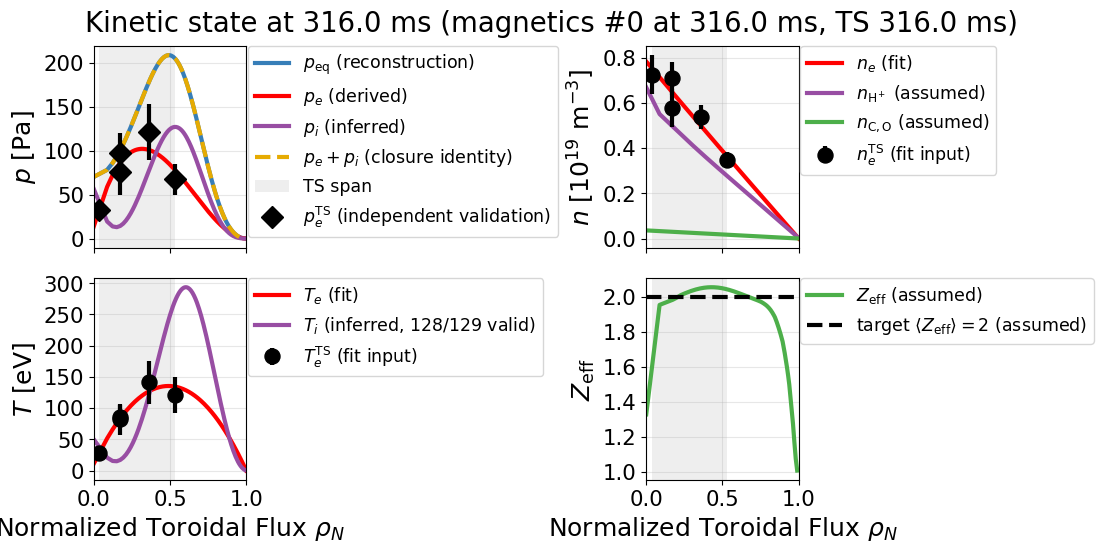

In [ ]:
fig_2x2, axes_2x2 = vaft.omas.plot_kinetic_overview_state(state.ods, format="slide")
plt.show()

### 4×1 layout

The same four panels in one column (`layout="stack"`); VAFT’s `poster` format sets the canvas and typography.

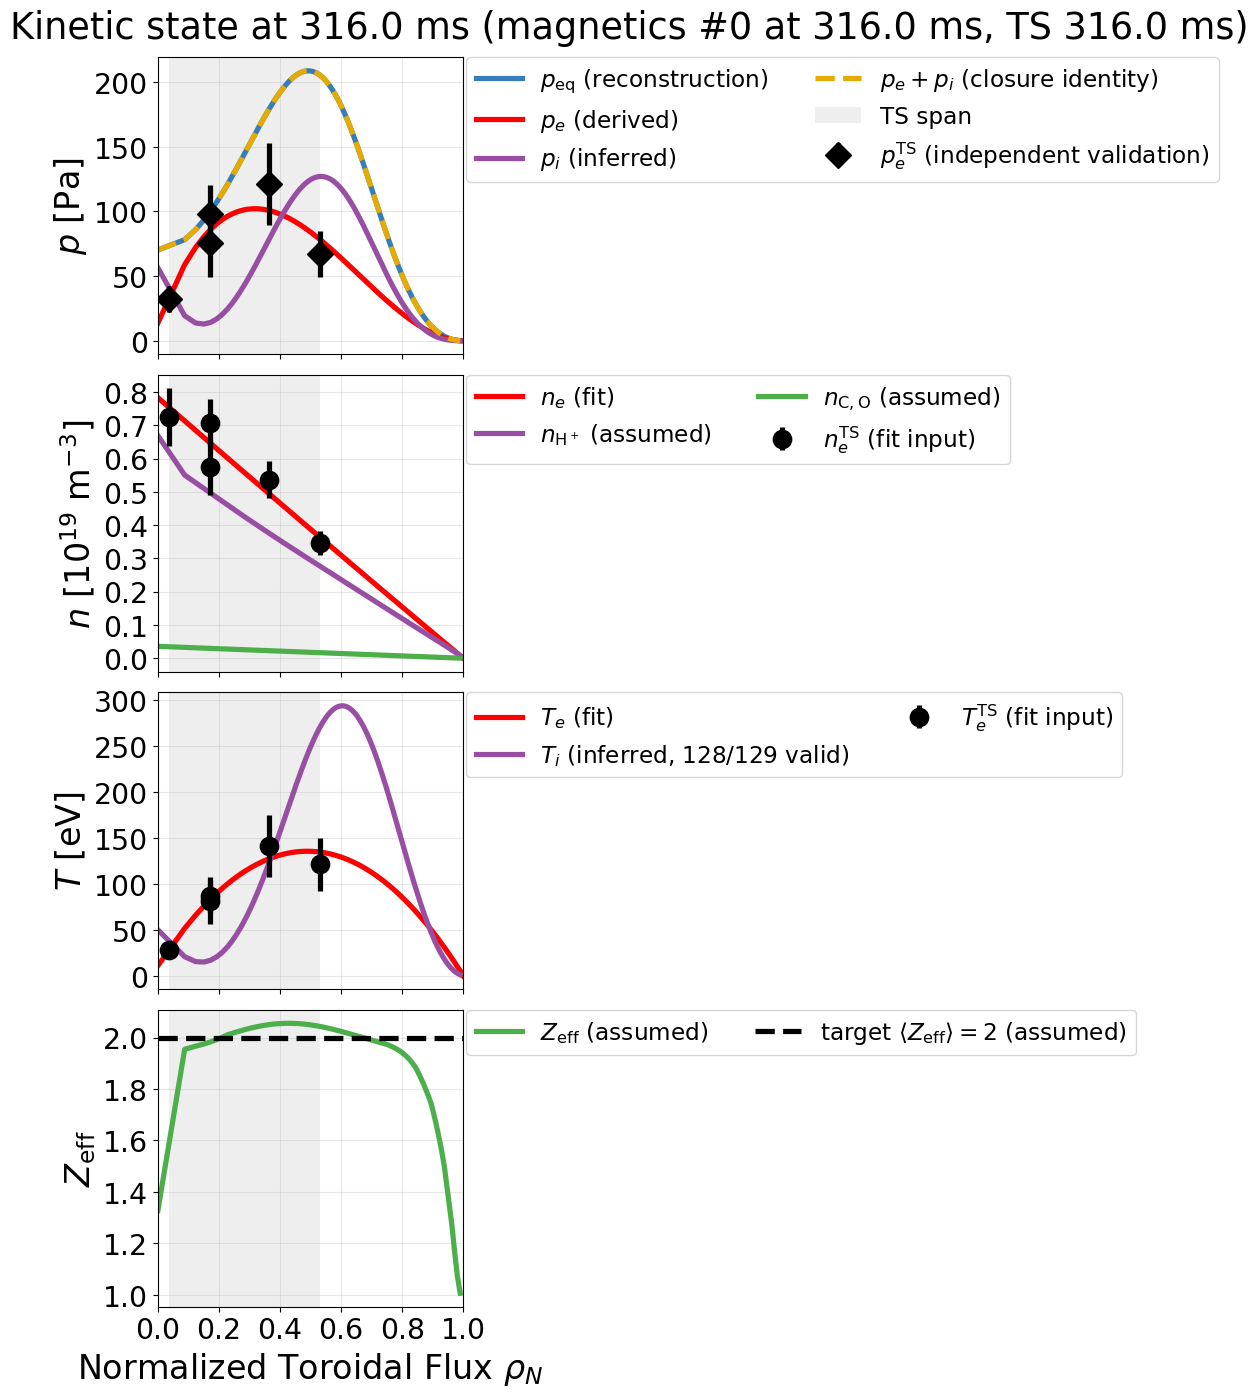

In [ ]:
fig_4x1, axes_4x1 = vaft.omas.plot_kinetic_overview_state(state.ods, layout="stack", format="poster")
plt.show()

### What the plot reads

`vaft.omas.plot_kinetic_overview_state` reads a completed `core_profiles` slice, the time-matched equilibrium and the Thomson channels, and maps the channels through that equilibrium itself. It refuses a `core_profiles` grid whose `rho_tor_norm` is the $\sqrt{\psi_N}$ proxy, an equilibrium more than one time step from the kinetic state, and an `equilibrium_occurrence=` other than the one the state records. It runs no EFIT, Thomson fit, OpenADAS or composition: the physics stays upstream (here, in the cells above and the converter), and the archive snapshot is an input fixture, not a hidden default shot in the public API.

## 6. A small diagnostic residual view

The normalized residuals refer only to the two fitted electron channels at the measured positions. $T_i$, ion densities, and $Z_{\rm eff}$ have no direct diagnostic points in this case; their apparent smoothness is model structure, not measurement density.

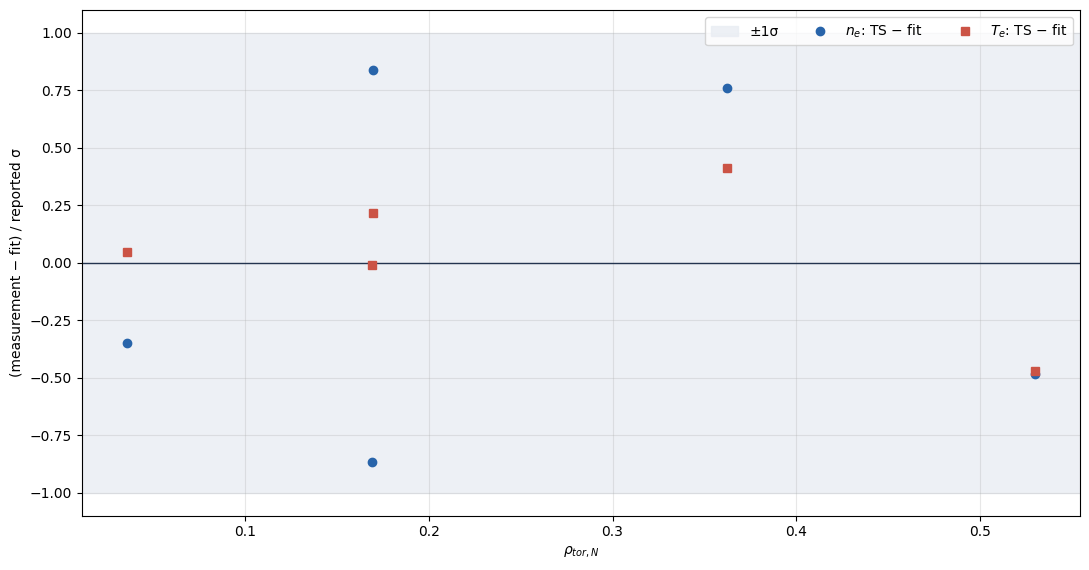

In [ ]:
fig, ax = plt.subplots(figsize=(FORMATS["slide"].width_in, FORMATS["slide"].max_height_in))
ax.axhspan(-1,1,color="#e9edf3",alpha=.8,label="±1σ")
ax.axhline(0,color="#23344f",lw=1)
ax.plot(rho_ts,z_ne,"o",color="#2864aa",label=r"$n_e$: TS − fit")
ax.plot(rho_ts,z_te,"s",color="#cb5345",label=r"$T_e$: TS − fit")
ax.set(xlabel=r"$\rho_{tor,N}$",ylabel="(measurement − fit) / reported σ",
       title="")
ax.legend(ncol=3)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 7. Archivable state table

The following cell writes a compact CSV derived from the frozen snapshot. `origin` remains a property of each quantity: magnetic `p_eq`, reconstructed electron profiles, model-derived charge states/ion densities, and inferred `T_i`. The CSV includes every C and O charge-state density, including neutral states (q=0), and contains NaNs at invalid points. Re-running the notebook deterministically regenerates it.

In [ ]:
out = ROOT / "output" / "kinetic_state" / "vest_39915_316ms_transient_c_o_profiles.csv"
out.parent.mkdir(parents=True, exist_ok=True)
columns = ["rho_tor_norm","p_eq_Pa","p_e_Pa","p_i_Pa","p_kin_Pa",
           "n_e_m3","n_H_ion_m3","n_C_element_m3","n_O_element_m3",
           "n_C_ion_m3","n_O_ion_m3","n_imp_ion_m3","T_e_eV","T_i_eV","Z_eff",
           "charge_state_valid","T_i_valid"]
values = [rho,peq,pe,pi,pkin,ne,nH,nC,nO,nC_ion,nO_ion,nimp,te,ti,zeff,
          valid_charge.astype(int),valid_ti.astype(int)]
for element, density, fractions in (("C", nC, fC), ("O", nO, fO)):
    for charge in range(fractions.shape[1]):
        columns.append(f"n_{element}_q{charge}_m3")
        values.append(density * fractions[:, charge])
with out.open("w",newline="") as handle:
    writer=csv.writer(handle)
    writer.writerow(columns)
    writer.writerows(zip(*values))
print(out.relative_to(ROOT))
print("rows",len(rho),"sha256",hashlib.sha256(out.read_bytes()).hexdigest())

output/kinetic_state/vest_39915_316ms_transient_c_o_profiles.csv
rows 129 sha256 44763333ab9883c597964bc2f4a47b9d93082ba5fa4babc19808d42bcbe8f0ac


## Interpretation and limits

- This is **kinetic pressure closure on a fixed, independently magnetic equilibrium**. The pressure overlay is an algebraic identity after $T_i$ inference. A joint magnetic–kinetic equilibrium iteration would be a different workflow.
- $\langle Z_{\rm eff}\rangle_{n_e dV}=2$ and equal C/O elemental densities are premises. The transient charge states turn them into a non-flat local $Z_{\rm eff}(\rho)$; no spectroscopic or resistive result identifies this composition for shot 39915.
- The reported Thomson range ends near $\rho=0.53$. Profile shapes and inferred $T_i$ outside it depend strongly on the fit and assumed composition. There is no propagated uncertainty for $T_i$, $n_{\rm imp}$, or $Z_{\rm eff}$.
- The source `core_profiles` product has no measured/stored ion or $Z_{\rm eff}$ profile for this slice. The model-derived state here is reproducible from the snapshot but has not been written back to that source product.

## 8. Electron-kinetic EFIT: assumption-aware check

The same shot also has an `electron_efit` product at 316 ms. Its `raw6` pressure constraint used five Thomson channels, an edge anchor, and the VEST fallback $T_i=T_e$ with $n_i=n_e$ (**no impurity dilution**). It is a **converged reconstruction** (manifest $\chi^2=87.72$), but the state atlas marks `kinetic_admissible=fail`: the reconstructed edge pressure reaches $-0.845745309$ Pa. Thus this section is a diagnostic comparison, not an accepted self-consistent C/O equilibrium.

The earlier C/O state uses $n_i<n_e$ and an independently magnetic $p_{\rm eq}$ to infer $T_i$. The kinetic EFIT instead already contains the $T_i/T_e$ prior. VAFT's pressure-partition guard must reject a second inference from this pressure. The archived snapshot pins the kinetic product and its manifest and state-atlas SHA-256 values.

In [ ]:
kin = s["electron_kinetic_equilibrium"]
assessment = s["electron_kinetic_assessment"]
rho_kin = np.asarray(kin["rho_tor_norm"], float)
psi_kin = np.asarray(kin["psi_Wb"], float)
peq_kin = np.asarray(kin["pressure_Pa"], float)
assert kin["time_s"] == eq["time_s"] == cp["time_s"] == s["time_s"]
assert assessment["lineage"] == "electron_kinetic"
assert assessment["ti_lineage"] == "ti_eq_te_assumed"
assert assessment["ti_te_ratio_assumed"] == 1.0
assert assessment["pressure_constraint_encoding"] == "raw6"
assert assessment["manifest_status"] == "success" and assessment["manifest_converged"]
assert assessment["atlas_efit_status"] == "valid"
assert assessment["atlas_kinetic_admissible"] == "fail"
assert assessment["atlas_ts_status"] == "matched" and assessment["atlas_ts_points"] == len(rho_ts)
assert np.all(np.diff(rho_kin) > 0)
np.testing.assert_allclose(peq_kin.min(), -0.845745309, atol=1e-10)
assert np.count_nonzero(peq_kin < 0) == 4
print("Kinetic EFIT time:", kin["time_s"], "s; negative-pressure cells:",
      np.count_nonzero(peq_kin < 0), "/", len(peq_kin))
print("Native rho-grid maximum shift:", np.max(np.abs(rho_kin-rho)))
print("Native psi-grid maximum shift:", np.max(np.abs(psi_kin-psi)), "Wb")
print("State-atlas kinetic admissibility:", assessment["atlas_kinetic_admissible"],
      "—", assessment["atlas_kinetic_admissible_reasons"])

refused = infer_ti_pressure_partition(
    peq_kin[0], ne[0], te[0],
    composition={"ion_density_per_electron": float(nion[0]/ne[0]),
                 "composition_source": "assumed transient C/O"},
    sigma_p_eq=np.nan, sigma_n_e=np.nan, sigma_t_e=np.nan,
    equilibrium_lineage=assessment["lineage"],
)
assert refused["eligible"] is False and "circular" in refused["reason"]
print("VAFT Ti-inference guard:", refused["reason"])

Kinetic EFIT time: 0.316 s; negative-pressure cells: 4 / 129
Native rho-grid maximum shift: 0.01169741227252652
Native psi-grid maximum shift: 0.0010653747015705144 Wb
State-atlas kinetic admissibility: fail — pressure_min -0.845745309
VAFT Ti-inference guard: circular: the 'electron_kinetic' equilibrium pressure was reconstructed with an assumed Ti/Te, so partitioning it returns that assumption


### Pressure constraint and C/O dilution

The `raw6` fit used $p_{\rm input}=e n_e(T_e+T_i)=2p_e$ at the **five measured Thomson channels**, plus a zero-pressure edge anchor. Its uncertainty includes the VEST $T_i/T_e=1\pm0.5$ prior and the shared $T_e$ error. The continuous $2p_e$ curve below uses the separate `core_profiles` fit and is only a reconstruction of that prior, **not the actual six EFIT input points**. Applying the notebook's C/O composition to the same $T_i=T_e$ premise would instead give $p_e(1+n_{i,\mathrm{charged}}/n_e)$; this was **not** the input used to reconstruct the stored kinetic EFIT.

The kinetic and magnetic equilibria have different flux grids. Each curve is drawn on its **own** $\rho_{\rm tor,N}$ labels. Thomson markers retain their archived magnetic-EFIT mapping; they are not remapped measurements on the kinetic equilibrium. The state atlas separately reports a matched five-channel comparison on the kinetic equilibrium.

In [ ]:
ratio = assessment["ti_te_ratio_assumed"]
p_prior_fit = (1 + ratio) * pe
p_co_fit = pe + E*nion*te
p_raw_ts = (1 + ratio) * p_ts
# Raw fallback propagates the shared Te error once and sigma(Ti/Te)=0.5.
ratio_sigma = 0.5
sp_raw_ts = E*np.sqrt(((1+ratio)*te_ts*sne_ts)**2
                        + ((1+ratio)*ne_ts*ste_ts)**2
                        + (ne_ts*te_ts*ratio_sigma)**2)
np.testing.assert_allclose(p_raw_ts, 2*p_ts, rtol=0, atol=0)
assert np.all(sp_raw_ts >= 0)
assert np.all(p_co_fit[valid_charge] <= p_prior_fit[valid_charge] + 1e-10)
print(f"Raw TS pressure constraints: {len(p_raw_ts)} measured points + 1 edge anchor")
print(f"Kinetic EFIT p_eq min/max: {peq_kin.min():.3f}/{peq_kin.max():.3f} Pa")
print(f"C/O dilution: n_i/n_e = {np.nanmin(nion[valid_charge]/ne[valid_charge]):.3f}–"
      f"{np.nanmax(nion[valid_charge]/ne[valid_charge]):.3f} on finite charge-state points")
print(f"Kinetic atlas r_w = {assessment['atlas_r_w']:.6f}; "
      f"on magnetic pair's common psi span = {assessment['atlas_r_w_on_pair_span']:.6f}; "
      f"c_p = {assessment['atlas_c_p']:+.6f}")

Raw TS pressure constraints: 5 measured points + 1 edge anchor
Kinetic EFIT p_eq min/max: -0.846/207.410 Pa
C/O dilution: n_i/n_e = 0.805–0.997 on finite charge-state points
Kinetic atlas r_w = 1.865508; on magnetic pair's common psi span = 1.823902; c_p = -0.003587


### Four-panel comparison using `vaft.plot`

The pressure panel contrasts the stored kinetic equilibrium, magnetic equilibrium, the two explicit $T_i=T_e$ pressure policies, and measured Thomson pressure constraints. The remaining panels keep the same electron fit and **assumed/model-derived** C/O state to make their provenance visible; they do not claim that this state was used by the kinetic EFIT. No $T_i$ is inferred from the kinetic pressure.

In [ ]:
from dataclasses import replace

kinetic_models = (
    Profile1D(series=(
        profile(rho_kin, peq_kin, r"$p_{\mathrm{eq}}^{\mathrm{kin}}$", color="palette:0"),
        profile(rho, peq, r"$p_{\mathrm{eq}}^{\mathrm{mag}}$", color="palette:7", ls="--"),
        profile(rho, p_prior_fit, r"$2p_e^{\mathrm{fit}}$", color="role:reconstructed"),
        profile(rho, p_co_fit, r"$p_e+p_i^{\mathrm{C/O}}$", color="palette:2",
                ls="--", mask=valid_charge),
        profile(rho_ts, p_raw_ts, r"$2p_e^{\mathrm{TS}}\pm1\sigma$", color="role:measured",
                yerr=sp_raw_ts, marker="D", ls="none"),
    ), coordinate_label=xlabel, y_label=r"$p$", y_unit="Pa",
       title="", x_limits=(0, 1),
       metadata={"kinetic_efit": "Ti=Te, ni=ne input; negative edge pressure fails admissibility"}),
    replace(models[1], reference_lines=()),  # the plot's panels; Thomson keeps its magnetic mapping
    Profile1D(series=(
        profile(rho, te, r"$T_e$", color="role:reconstructed"),
        profile(rho, te, r"$T_i=T_e$", color="palette:2", ls="--"),
        profile(rho_ts, te_ts, r"$T_e^{\mathrm{TS}}\pm1\sigma$", color="role:measured",
                yerr=ste_ts, marker="o", ls="none"),
    ), coordinate_label=xlabel, y_label=r"$T$", y_unit="eV",
       title="", x_limits=(0, 1)),
    replace(models[3], reference_lines=()),
)
assert all(isinstance(m, Profile1D) for m in kinetic_models)
print("Built", len(kinetic_models), "VAFT view models for the electron-kinetic EFIT check.")

Built 4 VAFT view models for the electron-kinetic EFIT check.


#### 2×2 layout

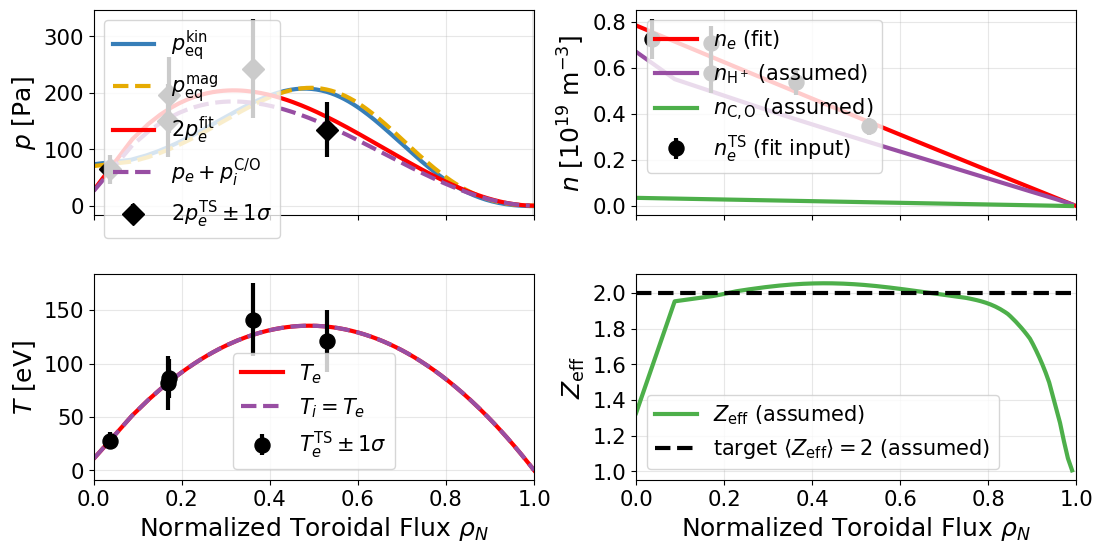

In [ ]:
kinetic_grid = Panels(models=kinetic_models, nrows=2, ncols=2, share_x=True)
fig_kin_2x2, axes_kin_2x2 = render_panels(kinetic_grid, format="slide")
plt.show()

#### 4×1 layout

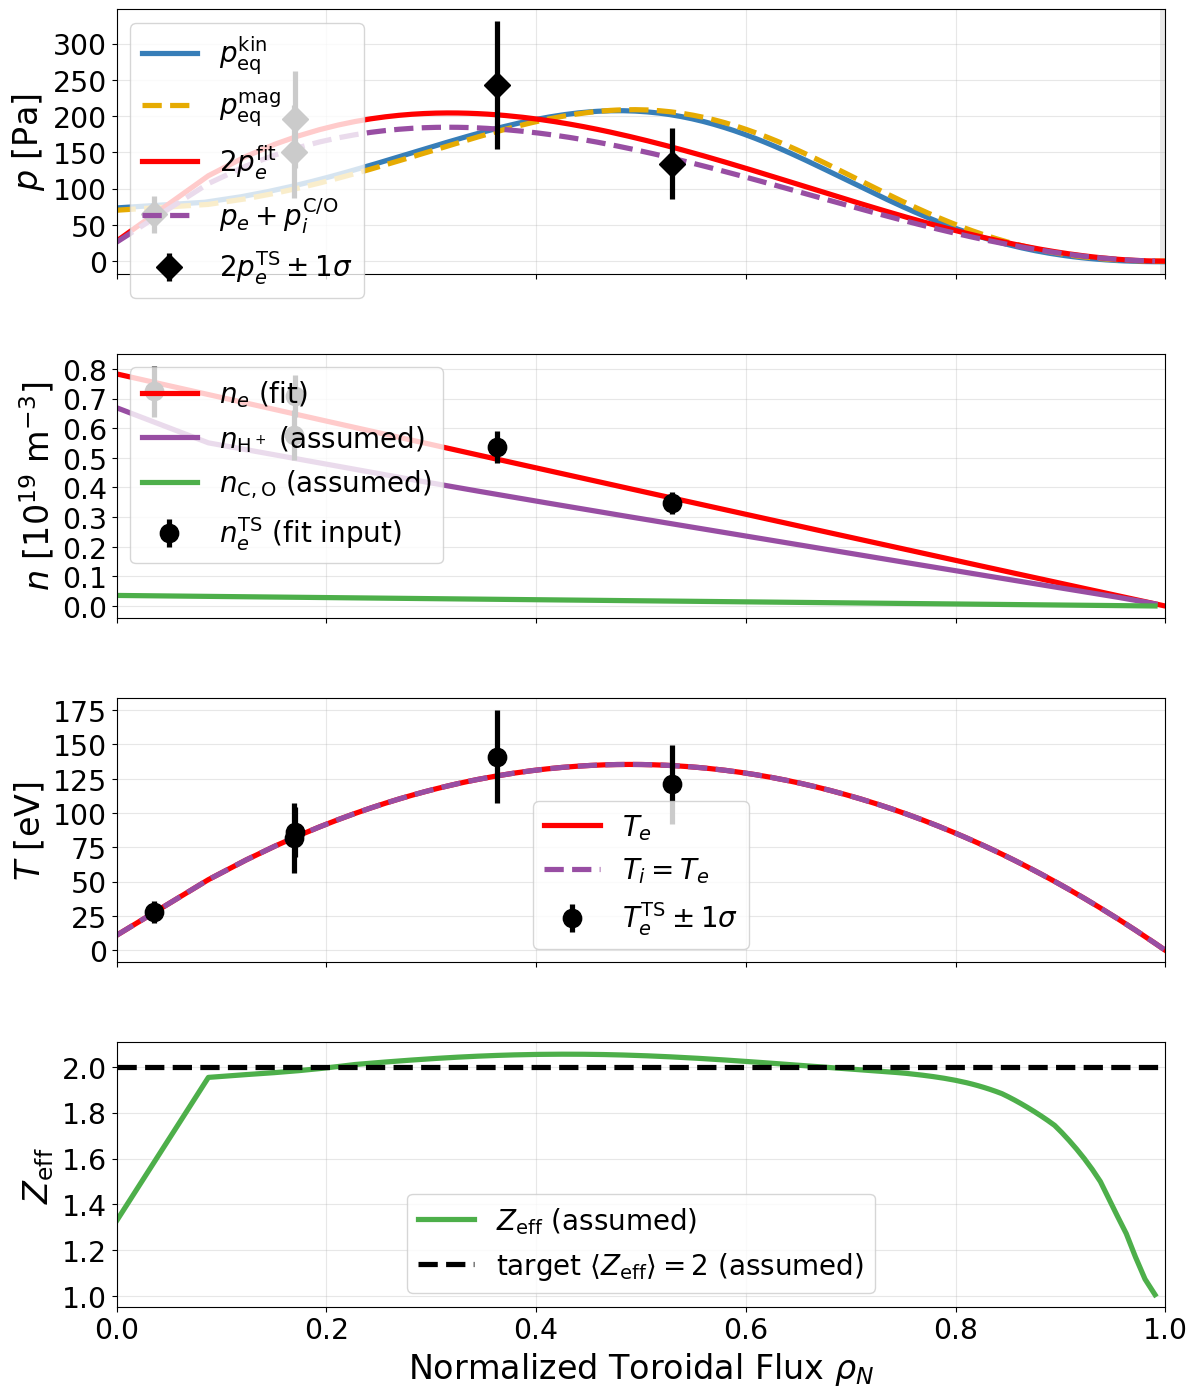

In [ ]:
kinetic_stack = Panels(models=kinetic_models, nrows=4, ncols=1, share_x=True)
fig_kin_4x1, axes_kin_4x1 = render_panels(kinetic_stack, format="poster")
plt.show()

### Result

The 316 ms electron-kinetic reconstruction and Thomson channels are time matched, and its state-atlas pressure ratio on the magnetic pair's common flux interval is $r_w=1.823902$ ($c_p=-0.003587$ relative to the magnetic row). These values are an **alignment diagnostic** for a fit that already used Thomson pressure, not independent evidence for $T_i$. The four negative-pressure edge cells make this equilibrium fail the kinetic admissibility gate. In particular, the archive does **not** establish a fully self-consistent H/C/O, $\langle Z_{\rm eff}\rangle=2$ kinetic EFIT: that would require refitting the equilibrium with an impurity-diluted pressure constraint and then reassessing flux mapping, diagnostics and admissibility.